# Plot history

In this file, we are going to plot the results of our simulation.

We will perform the following actions:
* Plot the real values of the PDE function
* Plot the estimated PDE values generated using Monte Carlo simulation

Please run the following codes:

## Table of Content

- [1 - Packages](#1)
- [2 - Plotting the results of our simulation](#2)
    - [2.1 - d=1 equation (real case)](#2-1)
        - [2.1.1 - Load the relevant csv files](#2-1-1)
        - [2.1.2 - Plot the PDE in one dimension: fix z=1 and varies t within [0, 1.0]](#2-1-2)
    - [2.2 - d=2 equation (real case)](#2-2)
        - [2.1.1 - Load the relevant csv files](#2-2-1)
        - [2.1.2 - Plot the PDE in two dimension: fix z=(1,1) and varies t within [0, 1.0]](#2-2-2)
    - [2.3 - d=3 equation (real case)](#2-3)
        - [2.1.1 - Load the relevant csv files](#2-3-1)
        - [2.1.2 - Plot the PDE in three dimension: fix z=(1,1,1) and varies t within [0, 1.0]](#2-3-2)
    - [2.4 - d=1 equation (complex case)](#2-4)
        - [2.4.1 - Load the relevant csv files](#2-4-1)
        - [2.4.2 - Plot the PDE in one dimension: fix z=1 and varies t within [0, 1.0]](#2-4-2)
    - [2.5 - d=2 equation (complex case)](#2-5)
        - [2.5.1 - Load the relevant csv files](#2-5-1)
        - [2.5.2 - Plot the PDE in two dimension: fix z=(1,1) and varies t within [0, 1.0]](#2-5-2)
    - [2.6 - d=3 equation (complex case)](#2-6)
        - [2.6.1 - Load the relevant csv files](#2-6-1)
        - [2.6.2 - Plot the PDE in three dimension: fix z=(1,1,1) and varies t within [0, 1.0]](#2-6-2)

<a name='1'></a>
## 1 - Packages

Run the cell below to import all the libraries you'll need:

In [1]:
# From system
import os
import shutil
from pathlib import Path
import random

# Data structure
import numpy as np
import pandas as pd
import json
import csv

# Plotting graph
from matplotlib import pyplot as plt

<a name='2'></a>
## 2 - Plotting the results of our simulation

<a name='2-1'></a>
### 2.1 - d=1 equation (real case)

The wave equation is:

$\frac{\partial^2 u}{\partial t^2}(z,t)-(1)^2\Big[\frac{\partial^2 u}{\partial z^2}(z,t)\Big] = -\frac{4\omega^2}{3}\sin(u(z,t))$

$u(z,0) = \phi(z) = 4\arctan\big(\exp\big(\frac{4\omega}{3}z\big)\big)$

$\frac{\partial u}{\partial t}(z,0) = \psi(z) = \frac{8\omega\exp\big(\frac{4\omega}{3}z\big)}{3\big(1+\exp\big(\frac{8\omega}{3}z\big)\big)}$

where $\omega = 0.5 + 0i$.

The analytical solution is:

$u(z,t) = 4\arctan\Big(\exp\big(\frac{4\omega}{3}\big(z+\frac{t}{2}\big)\big)\Big)$

We set $a=1$, $z=1$, $\lambda = 1.0$, and sample $t \in [0,1.0]$ in steps of $0.1$ (11 time points).

<a name='2-1-1'></a>
#### 2.1.1 - Load the relevant csv files

In [2]:
np_dictionary = {}

dir_name = "real_d1_results"
os_listdir = os.listdir(dir_name)
for file_name in os_listdir:
    file_path = os.path.join(dir_name, file_name)
    data =  pd.read_csv(file_path, delimiter=',', dtype=None, header=None)
    np_dictionary[file_name[:-4]] = data

<a name='2-1-2'></a>
#### 2.1.2 - Plot the PDE in one dimension: fix z=1 and varies t within [0, 1.0]

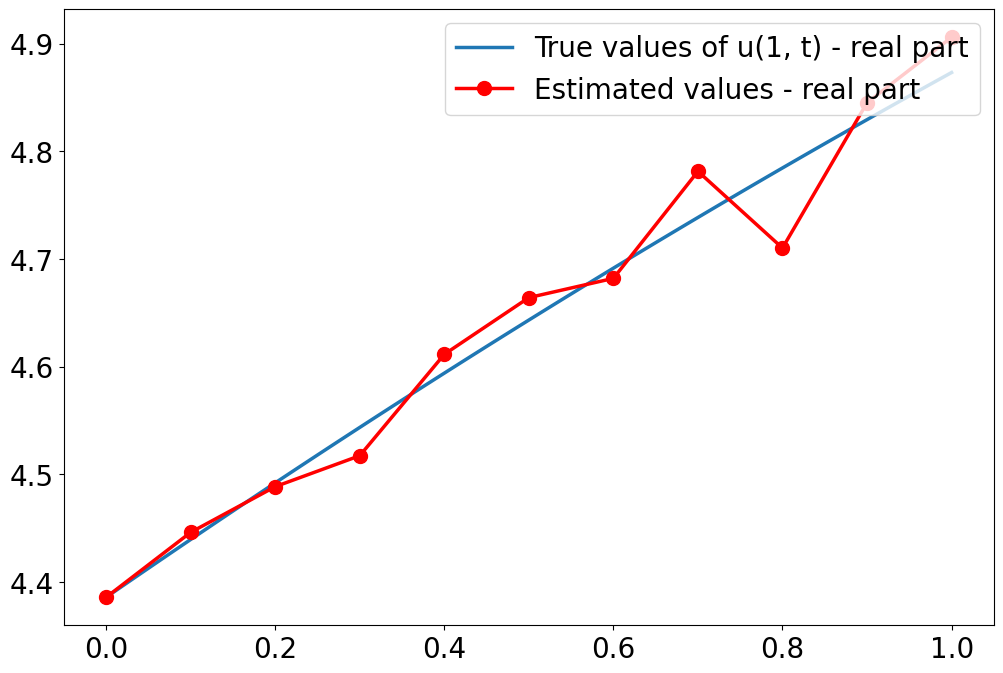

In [3]:
impose_ylim = False
y_lim = [4.35,4.95]

true_values_real = np.asarray(np_dictionary["analytic"])[0,:]
true_values_real = np.reshape(true_values_real, (101,))#[0:191]
t_values = np.arange(0, 1.01, 0.01)
estimated_values_real = np.asarray(np_dictionary["monte_carlo"])[0,:]
estimated_values_real = np.reshape(estimated_values_real, (11,))#[0:19]
t_estimated = np.arange(0, 1.1, 0.1)

plt.figure(figsize=(12, 8))
plt.plot(t_values, true_values_real, label='True values of u(1, t) - real part', lw=2.5)
plt.plot(t_estimated, estimated_values_real, 'ro-', label='Estimated values - real part', lw=2.5, ms=10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# plt.ylabel('true vs estimated values - real part')
if impose_ylim:
    plt.ylim(y_lim)
# plt.xlabel('t values')
# plt.axvline(x=0.32,color='red')

# plt.title('True vs estimated values of u(1, t) - real part')
plt.legend(loc='upper right',fontsize=20)
plt.show()

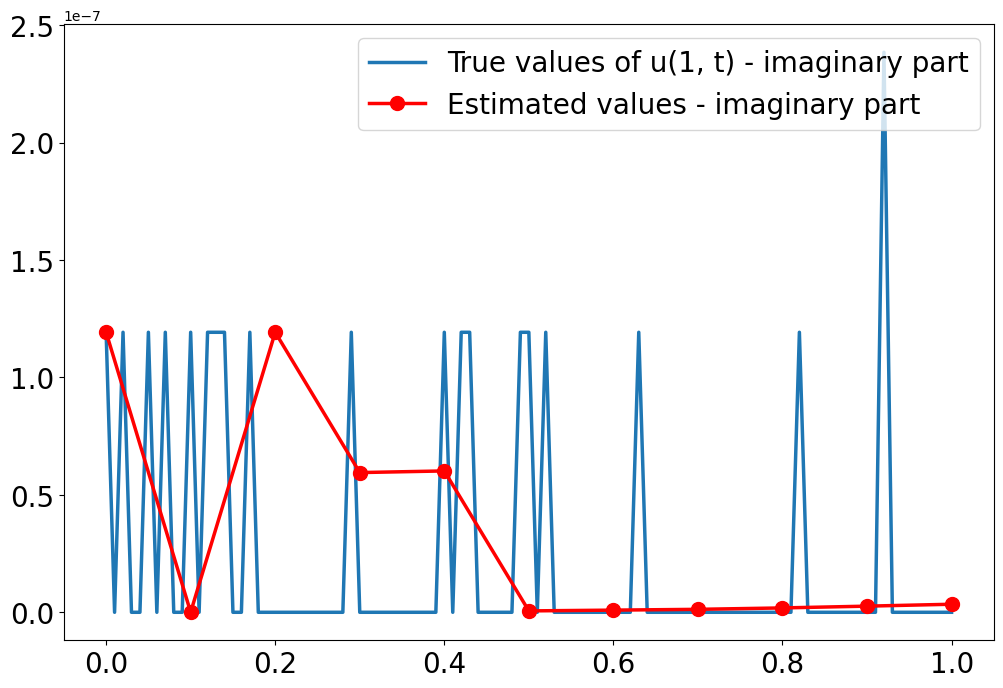

In [4]:
impose_ylim = False
y_lim = [-0.5,0]

true_values_imaginary = np.asarray(np_dictionary["analytic"])[1,:]
true_values_imaginary = np.reshape(true_values_imaginary, (101,))#[0:191]
t_values = np.arange(0, 1.01, 0.01)
estimated_values_imaginary = np.asarray(np_dictionary["monte_carlo"])[1,:]
estimated_values_imaginary = np.reshape(estimated_values_imaginary, (11,))#[0:19]
t_estimated = np.arange(0, 1.1, 0.1)

plt.figure(figsize=(12, 8))
plt.plot(t_values, true_values_imaginary, label='True values of u(1, t) - imaginary part', lw=2.5)
plt.plot(t_estimated, estimated_values_imaginary, 'ro-', label='Estimated values - imaginary part', lw=2.5, ms=10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# plt.ylabel('true vs estimated values - imaginary part')
plt.ylabel('')
if impose_ylim:
    plt.ylim(y_lim)
# plt.xlabel('t values')
plt.xlabel('')
# plt.axvline(x=0.32,color='red')

# plt.title('True vs estimated values of u(1, t) - imaginary part')
plt.legend(loc='upper right',fontsize=20)
plt.show()

<a name='2-2'></a>
### 2.2 - d=2 equation (real case)

The wave equation is:

$\frac{\partial^2 u}{\partial t^2}(z_1,z_2,t)-(\frac{1}{\sqrt{2}})^2\Big[\frac{\partial^2 u}{\partial z_1^2}(z_1,z_2,t)+\frac{\partial^2 u}{\partial z_2^2}(z_1,z_2,t)\Big] = -\frac{4\omega^2}{3}\sin(u(z_1,z_2,t))$

$u(z_1,z_2,0) = \phi(z_1,z_2) = 4\arctan\Big(\exp\Big(\frac{4\omega}{3}\big(z_1+z_2\big)\Big)\Big)$

$\frac{\partial u}{\partial t}(z_1,z_2,0) = \psi(z_1,z_2) = \frac{8\omega\exp\big(\frac{4\omega}{3}(z_1+z_2)\big)}{3\big(1+\exp\big(\frac{8\omega}{3}(z_1+z_2)\big)\big)}$

where $\omega = 0.5 + 0i$.

The analytical solution is:

$u(z_1,z_2,t) = 4\arctan\Big(\exp\Big(\frac{4\omega}{3}\big(z_1+z_2+\frac{t}{2}\big)\Big)\Big)$

We set $a=\frac{1}{\sqrt{2}}$, $z=(1,1)$, $\lambda = 1.0$, and sample $t \in [0,1.0]$ in steps of $0.1$ (11 time points).

<a name='2-2-1'></a>
#### 2.2.1 - Load the relevant csv files

In [5]:
np_dictionary = {}

dir_name = "real_d2_results"
os_listdir = os.listdir(dir_name)
for file_name in os_listdir:
    file_path = os.path.join(dir_name, file_name)
    data =  pd.read_csv(file_path, delimiter=',', dtype=None, header=None)
    np_dictionary[file_name[:-4]] = data

<a name='2-2-2'></a>
#### 2.2.2 - Plot the PDE in two dimension: fix z=(1,1) and varies t within [0, 1.0]

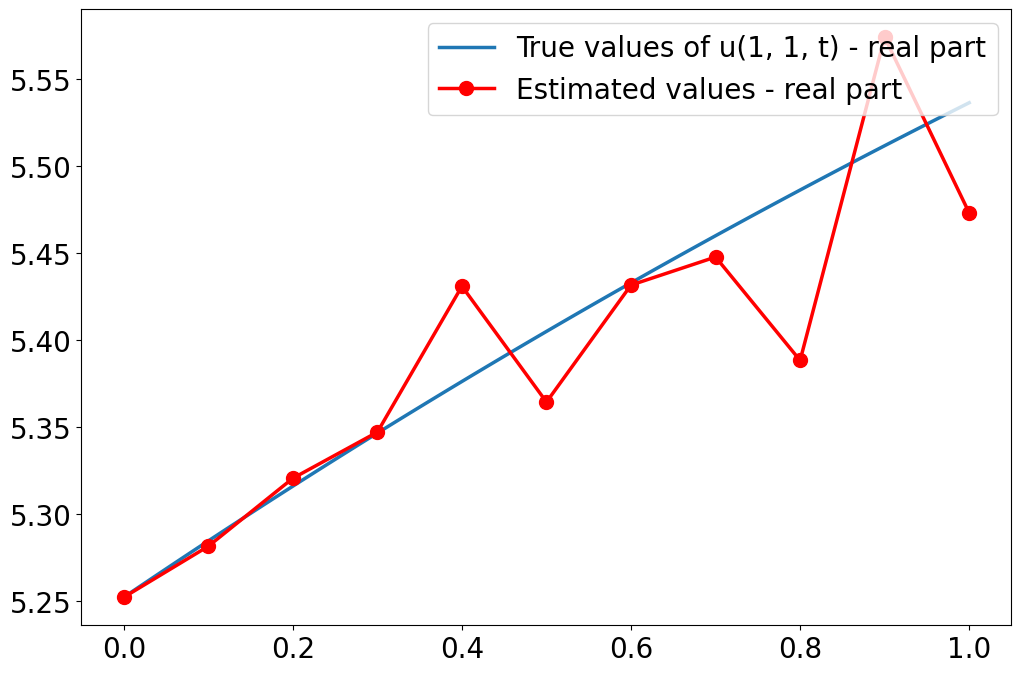

In [6]:
impose_ylim = False
y_lim = [5.25,5.60]

true_values_real = np.asarray(np_dictionary["analytic"])[0,:]
true_values_real = np.reshape(true_values_real, (101,))#[0:191]
t_values = np.arange(0, 1.01, 0.01)
estimated_values_real = np.asarray(np_dictionary["monte_carlo"])[0,:]
estimated_values_real = np.reshape(estimated_values_real, (11,))#[0:19]
t_estimated = np.arange(0, 1.1, 0.1)

plt.figure(figsize=(12, 8))
plt.plot(t_values, true_values_real, label='True values of u(1, 1, t) - real part', lw=2.5)
plt.plot(t_estimated, estimated_values_real, 'ro-', label='Estimated values - real part', lw=2.5, ms=10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# plt.ylabel('true vs estimated values - real part')
if impose_ylim:
    plt.ylim(y_lim)
# plt.xlabel('t values')
# plt.axvline(x=0.32,color='red')

# plt.title('True vs estimated values of u(1, 1, t) - real part')
plt.legend(loc='upper right',fontsize=20)
plt.show()

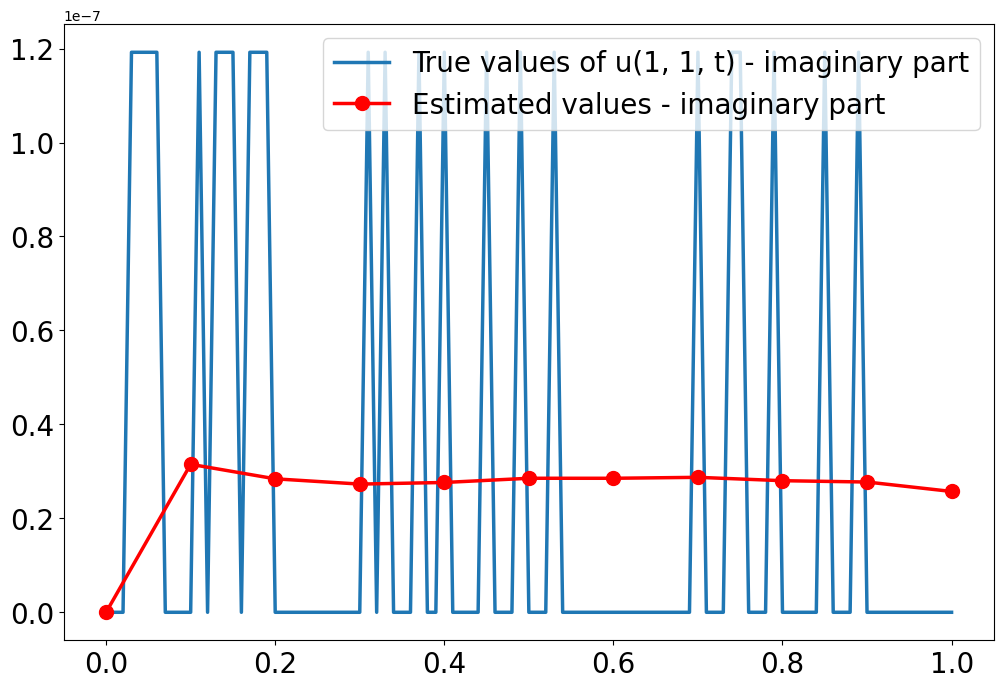

In [7]:
impose_ylim = False
y_lim = [-0.5,0]

true_values_imaginary = np.asarray(np_dictionary["analytic"])[1,:]
true_values_imaginary = np.reshape(true_values_imaginary, (101,))#[0:191]
t_values = np.arange(0, 1.01, 0.01)
estimated_values_imaginary = np.asarray(np_dictionary["monte_carlo"])[1,:]
estimated_values_imaginary = np.reshape(estimated_values_imaginary, (11,))#[0:19]
t_estimated = np.arange(0, 1.1, 0.1)

plt.figure(figsize=(12, 8))
plt.plot(t_values, true_values_imaginary, label='True values of u(1, 1, t) - imaginary part', lw=2.5)
plt.plot(t_estimated, estimated_values_imaginary, 'ro-', label='Estimated values - imaginary part', lw=2.5, ms=10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# plt.ylabel('true vs estimated values - imaginary part')
plt.ylabel('')
if impose_ylim:
    plt.ylim(y_lim)
# plt.xlabel('t values')
plt.xlabel('')
# plt.axvline(x=0.32,color='red')

# plt.title('True vs estimated values of u(1, 1, t) - imaginary part')
plt.legend(loc='upper right',fontsize=20)
plt.show()

<a name='2-3'></a>
### 2.3 - d=3 equation (real case)

The wave equation is:

$\frac{\partial^2 u}{\partial t^2}(z_1,z_2,z_3,t)-(\frac{1}{\sqrt{3}})^2\Big[\frac{\partial^2 u}{\partial z_1^2}(z_1,z_2,z_3,t)+\frac{\partial^2 u}{\partial z_2^2}(z_1,z_2,z_3,t)+\frac{\partial^2 u}{\partial z_3^2}(z_1,z_2,z_3,t)\Big] = -\frac{4\omega^2}{3}\sin(u(z_1,z_2,z_3,t))$

$u(z_1,z_2,z_3,0) = \phi(z_1,z_2,z_3) = 4\arctan\Big(\exp\Big(\frac{4\omega}{3}\big(z_1+z_2+z_3\big)\Big)\Big)$

$\frac{\partial u}{\partial t}(z_1,z_2,z_3,0) = \psi(z_1,z_2,z_3) = \frac{8\omega\exp\big(\frac{4\omega}{3}(z_1+z_2+z_3)\big)}{3\big(1+\exp\big(\frac{8\omega}{3}(z_1+z_2+z_3)\big)\big)}$

where $\omega = 0.5 + 0i$.

The analytical solution is:

$u(z_1,z_2,z_3,t) = 4\arctan\Big(\exp\Big(\frac{4\omega}{3}\big(z_1+z_2+z_3+\frac{t}{2}\big)\Big)\Big)$

We set $a=\frac{1}{\sqrt{3}}$, $z=(1,1,1)$, $\lambda = 1.0$, and sample $t \in [0,1.0]$ in steps of $0.1$ (11 time points).

<a name='2-3-1'></a>
#### 2.3.1 - Load the relevant csv files

In [8]:
np_dictionary = {}

dir_name = "real_d3_results"
os_listdir = os.listdir(dir_name)
for file_name in os_listdir:
    file_path = os.path.join(dir_name, file_name)
    data =  pd.read_csv(file_path, delimiter=',', dtype=None, header=None)
    np_dictionary[file_name[:-4]] = data

<a name='2-3-2'></a>
#### 2.3.2 - Plot the PDE in three dimension: fix z=(1,1,1) and varies t within [0, 1.0]

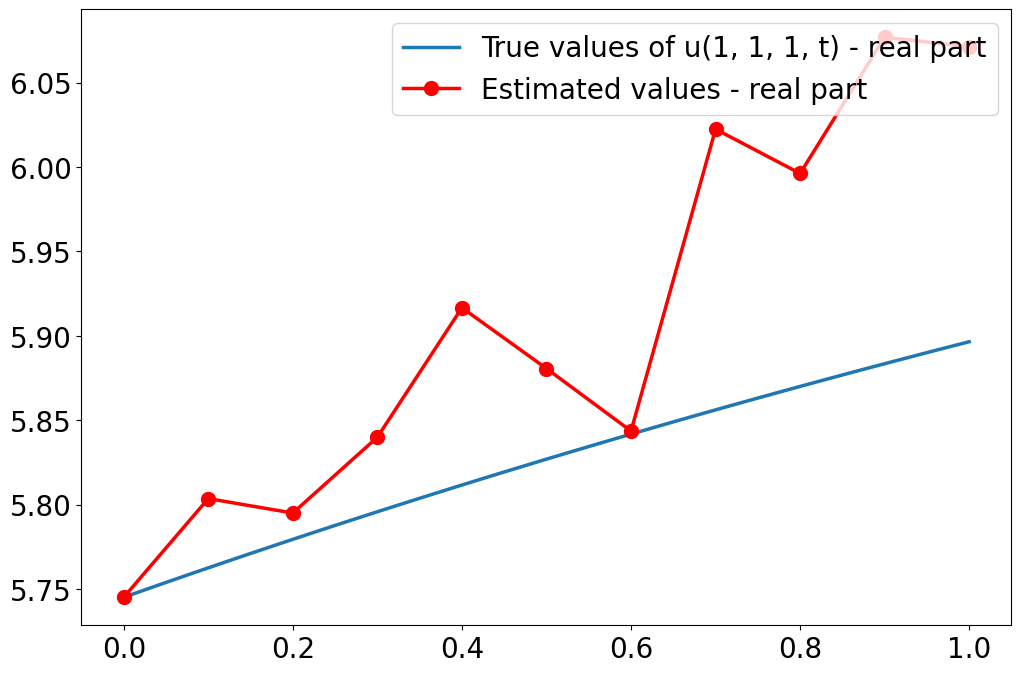

In [9]:
impose_ylim = False
y_lim = [5.70,6.10]

true_values_real = np.asarray(np_dictionary["analytic"])[0,:]
true_values_real = np.reshape(true_values_real, (101,))#[0:191]
t_values = np.arange(0, 1.01, 0.01)
estimated_values_real = np.asarray(np_dictionary["monte_carlo"])[0,:]
estimated_values_real = np.reshape(estimated_values_real, (11,))#[0:19]
t_estimated = np.arange(0, 1.1, 0.1)

plt.figure(figsize=(12, 8))
plt.plot(t_values, true_values_real, label='True values of u(1, 1, 1, t) - real part', lw=2.5)
plt.plot(t_estimated, estimated_values_real, 'ro-', label='Estimated values - real part', lw=2.5, ms=10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# plt.ylabel('true vs estimated values - real part')
if impose_ylim:
    plt.ylim(y_lim)
# plt.xlabel('t values')
# plt.axvline(x=0.32,color='red')

# plt.title('True vs estimated values of u(1, 1, 1, t) - real part')
plt.legend(loc='upper right',fontsize=20)
plt.show()

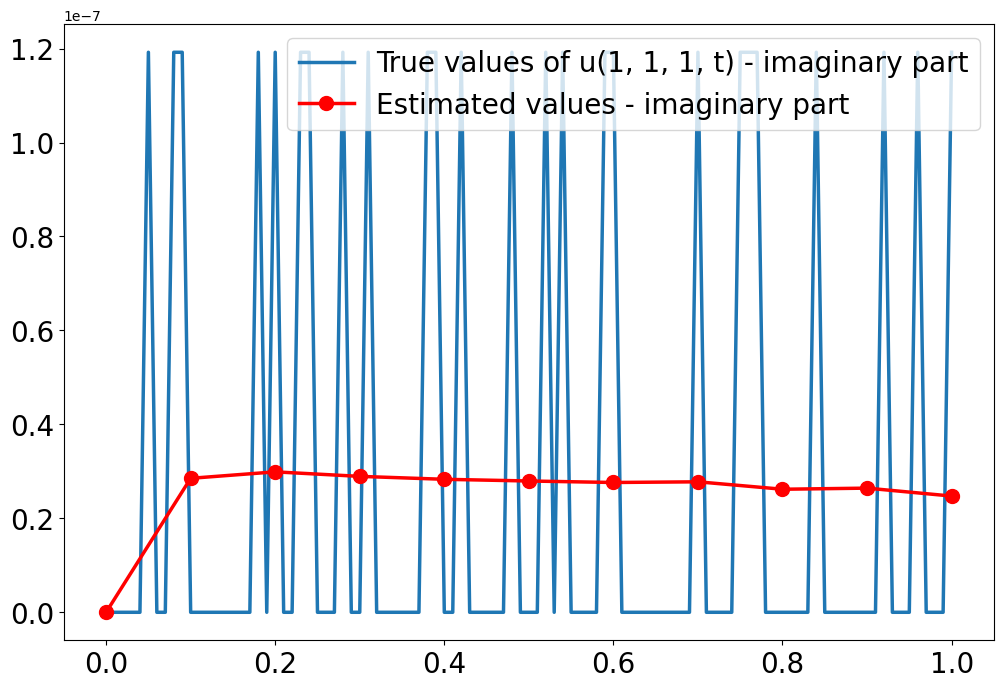

In [10]:
impose_ylim = False
y_lim = [-0.5,0]

true_values_imaginary = np.asarray(np_dictionary["analytic"])[1,:]
true_values_imaginary = np.reshape(true_values_imaginary, (101,))#[0:191]
t_values = np.arange(0, 1.01, 0.01)
estimated_values_imaginary = np.asarray(np_dictionary["monte_carlo"])[1,:]
estimated_values_imaginary = np.reshape(estimated_values_imaginary, (11,))#[0:19]
t_estimated = np.arange(0, 1.1, 0.1)

plt.figure(figsize=(12, 8))
plt.plot(t_values, true_values_imaginary, label='True values of u(1, 1, 1, t) - imaginary part', lw=2.5)
plt.plot(t_estimated, estimated_values_imaginary, 'ro-', label='Estimated values - imaginary part', lw=2.5, ms=10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# plt.ylabel('true vs estimated values - imaginary part')
plt.ylabel('')
if impose_ylim:
    plt.ylim(y_lim)
# plt.xlabel('t values')
plt.xlabel('')
# plt.axvline(x=0.32,color='red')

# plt.title('True vs estimated values of u(1, 1, 1, t) - imaginary part')
plt.legend(loc='upper right',fontsize=20)
plt.show()

<a name='2-4'></a>
### 2.4 - d=1 equation (complex case)

The wave equation is:

$\frac{\partial^2 u}{\partial t^2}(z,t)-(i)^2\Big[\frac{\partial^2 u}{\partial z^2}(z,t)\Big] = -\frac{4\omega^2}{3}\sin(u(z,t))$

$u(z,0) = \phi(z) = 4\arctan\big(\exp\big(\frac{4\omega}{3}iz\big)\big)$

$\frac{\partial u}{\partial t}(z,0) = \psi(z) = \frac{8\omega\exp\big(\frac{4\omega}{3}iz\big)}{3\big(1+\exp\big(\frac{8\omega}{3}iz\big)\big)}$

where $\omega = 0.5 + 0i$.

The analytical solution is:

$u(z,t) = 4\arctan\Big(\exp\big(\frac{4\omega}{3}\big(iz+\frac{t}{2}\big)\big)\Big)$

We set $a=i$, $z=1$, $\lambda = 1.0$, and sample $t \in [0,1.0]$ in steps of $0.1$ (11 time points).

<a name='2-4-1'></a>
#### 2.4.1 - Load the relevant csv files

In [11]:
np_dictionary = {}

dir_name = "complex_d1_results"
os_listdir = os.listdir(dir_name)
for file_name in os_listdir:
    file_path = os.path.join(dir_name, file_name)
    data =  pd.read_csv(file_path, delimiter=',', dtype=None, header=None)
    np_dictionary[file_name[:-4]] = data

<a name='2-4-2'></a>
#### 2.4.2 - Plot the PDE in one dimension: fix z=1 and varies t within [0, 1.0]

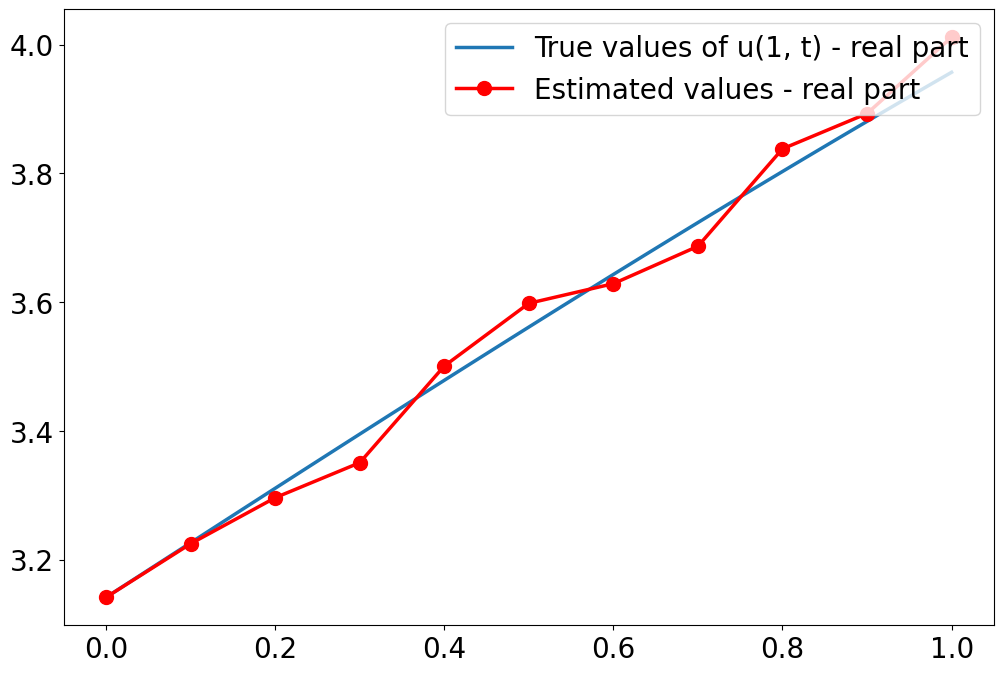

In [12]:
impose_ylim = False
y_lim = [4.35,4.95]

true_values_real = np.asarray(np_dictionary["analytic"])[0,:]
true_values_real = np.reshape(true_values_real, (101,))#[0:191]
t_values = np.arange(0, 1.01, 0.01)
estimated_values_real = np.asarray(np_dictionary["monte_carlo"])[0,:]
estimated_values_real = np.reshape(estimated_values_real, (11,))#[0:19]
t_estimated = np.arange(0, 1.1, 0.1)

plt.figure(figsize=(12, 8))
plt.plot(t_values, true_values_real, label='True values of u(1, t) - real part', lw=2.5)
plt.plot(t_estimated, estimated_values_real, 'ro-', label='Estimated values - real part', lw=2.5, ms=10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# plt.ylabel('true vs estimated values - real part')
if impose_ylim:
    plt.ylim(y_lim)
# plt.xlabel('t values')
# plt.axvline(x=0.32,color='red')

# plt.title('True vs estimated values of u(1, t) - real part')
plt.legend(loc='upper right',fontsize=20)
plt.show()

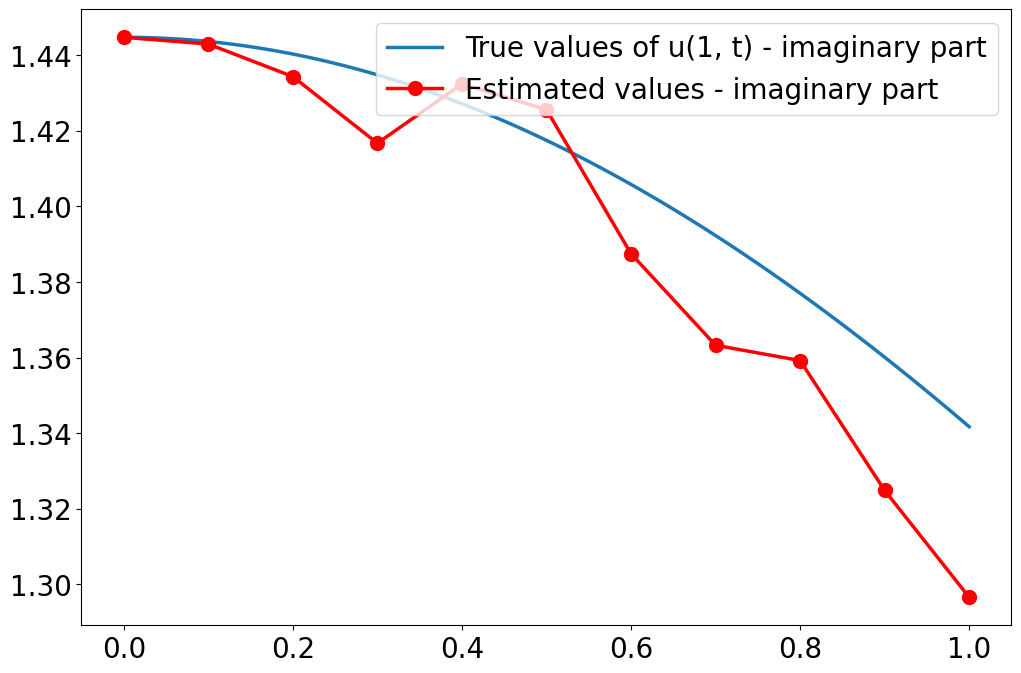

In [13]:
impose_ylim = False
y_lim = [-0.5,0]

true_values_imaginary = np.asarray(np_dictionary["analytic"])[1,:]
true_values_imaginary = np.reshape(true_values_imaginary, (101,))#[0:191]
t_values = np.arange(0, 1.01, 0.01)
estimated_values_imaginary = np.asarray(np_dictionary["monte_carlo"])[1,:]
estimated_values_imaginary = np.reshape(estimated_values_imaginary, (11,))#[0:19]
t_estimated = np.arange(0, 1.1, 0.1)

plt.figure(figsize=(12, 8))
plt.plot(t_values, true_values_imaginary, label='True values of u(1, t) - imaginary part', lw=2.5)
plt.plot(t_estimated, estimated_values_imaginary, 'ro-', label='Estimated values - imaginary part', lw=2.5, ms=10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# plt.ylabel('true vs estimated values - imaginary part')
plt.ylabel('')
if impose_ylim:
    plt.ylim(y_lim)
# plt.xlabel('t values')
plt.xlabel('')
# plt.axvline(x=0.32,color='red')

# plt.title('True vs estimated values of u(1, t) - imaginary part')
plt.legend(loc='upper right',fontsize=20)
plt.show()

<a name='2-5'></a>
### 2.5 - d=2 equation (complex case)

The wave equation is:

$\frac{\partial^2 u}{\partial t^2}(z_1,z_2,t)-(\frac{i}{\sqrt{2}})^2\Big[\frac{\partial^2 u}{\partial z_1^2}(z_1,z_2,t)+\frac{\partial^2 u}{\partial z_2^2}(z_1,z_2,t)\Big] = -\frac{4\omega^2}{3}\sin(u(z_1,z_2,t))$

$u(z_1,z_2,0) = \phi(z_1,z_2) = 4\arctan\Big(\exp\Big(\frac{4\omega}{3}\big(iz_1+iz_2\big)\Big)\Big)$

$\frac{\partial u}{\partial t}(z_1,z_2,0) = \psi(z_1,z_2) = \frac{8\omega\exp\big(\frac{4\omega}{3}(iz_1+iz_2)\big)}{3\big(1+\exp\big(\frac{8\omega}{3}(iz_1+iz_2)\big)\big)}$

where $\omega = 0.5 + 0i$.

The analytical solution is:

$u(z_1,z_2,t) = 4\arctan\Big(\exp\Big(\frac{4\omega}{3}\big(iz_1+iz_2+\frac{t}{2}\big)\Big)\Big)$

We set $a=\frac{i}{\sqrt{2}}$, $z=(1,1)$, $\lambda = 1.0$, and sample $t \in [0,1.0]$ in steps of $0.1$ (11 time points).

<a name='2-5-1'></a>
#### 2.5.1 - Load the relevant csv files

In [14]:
np_dictionary = {}

dir_name = "complex_d2_results"
os_listdir = os.listdir(dir_name)
for file_name in os_listdir:
    file_path = os.path.join(dir_name, file_name)
    data =  pd.read_csv(file_path, delimiter=',', dtype=None, header=None)
    np_dictionary[file_name[:-4]] = data

<a name='2-5-2'></a>
#### 2.5.2 - Plot the PDE in two dimension: fix z=(1,1) and varies t within [0, 1.0]

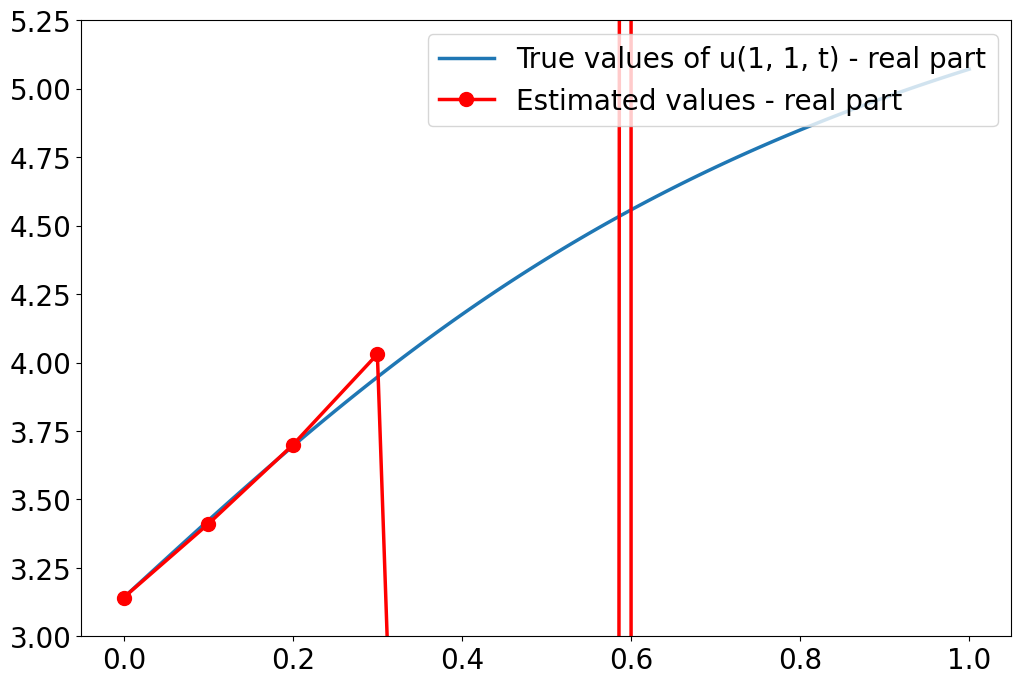

In [15]:
impose_ylim = True
y_lim = [3.00,5.25]

true_values_real = np.asarray(np_dictionary["analytic"])[0,:]
true_values_real = np.reshape(true_values_real, (101,))#[0:191]
t_values = np.arange(0, 1.01, 0.01)
estimated_values_real = np.asarray(np_dictionary["monte_carlo"])[0,0:8]
estimated_values_real = np.reshape(estimated_values_real, (8,))#[0:19]
t_estimated = np.arange(0, 0.8, 0.1)

plt.figure(figsize=(12, 8))
plt.plot(t_values, true_values_real, label='True values of u(1, 1, t) - real part', lw=2.5)
plt.plot(t_estimated, estimated_values_real, 'ro-', label='Estimated values - real part', lw=2.5, ms=10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# plt.ylabel('true vs estimated values - real part')
if impose_ylim:
    plt.ylim(y_lim)
# plt.xlabel('t values')
# plt.axvline(x=0.32,color='red')

# plt.title('True vs estimated values of u(1, 1, t) - real part')
plt.legend(loc='upper right',fontsize=20)
plt.show()

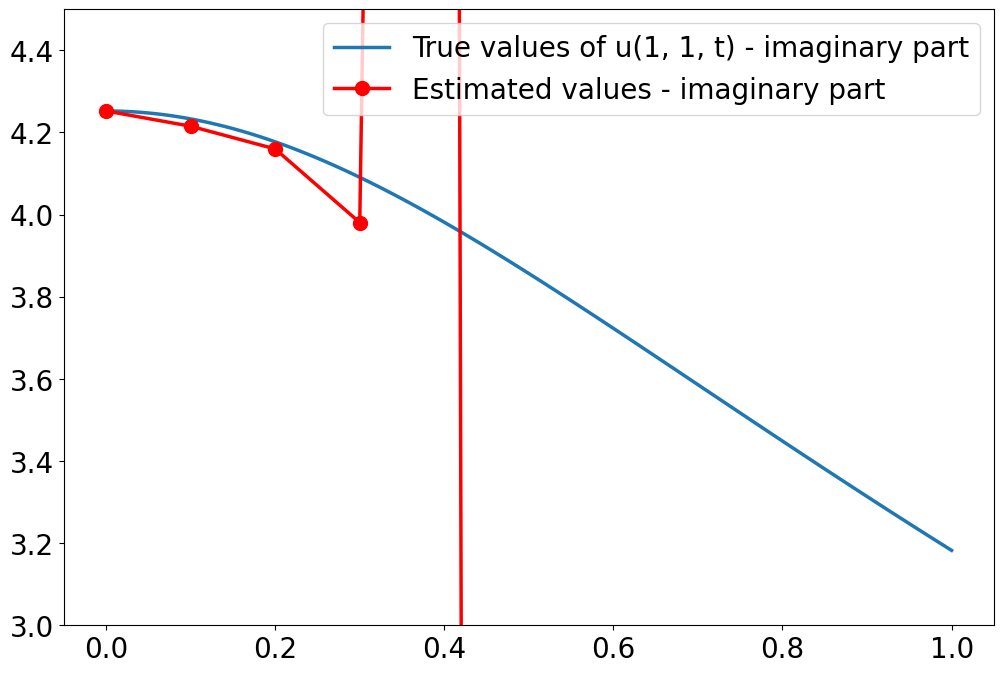

In [16]:
impose_ylim = True
y_lim = [3.0,4.5]

true_values_imaginary = np.asarray(np_dictionary["analytic"])[1,:]
true_values_imaginary = np.reshape(true_values_imaginary, (101,))#[0:191]
t_values = np.arange(0, 1.01, 0.01)
estimated_values_imaginary = np.asarray(np_dictionary["monte_carlo"])[1,0:8]
estimated_values_imaginary = np.reshape(estimated_values_imaginary, (8,))#[0:19]
t_estimated = np.arange(0, 0.8, 0.1)

plt.figure(figsize=(12, 8))
plt.plot(t_values, true_values_imaginary, label='True values of u(1, 1, t) - imaginary part', lw=2.5)
plt.plot(t_estimated, estimated_values_imaginary, 'ro-', label='Estimated values - imaginary part', lw=2.5, ms=10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# plt.ylabel('true vs estimated values - imaginary part')
plt.ylabel('')
if impose_ylim:
    plt.ylim(y_lim)
# plt.xlabel('t values')
plt.xlabel('')
# plt.axvline(x=0.32,color='red')

# plt.title('True vs estimated values of u(1, 1, t) - imaginary part')
plt.legend(loc='upper right',fontsize=20)
plt.show()

<a name='2-6'></a>
### 2.6 - d=3 equation (complex case)

The wave equation is:

$\frac{\partial^2 u}{\partial t^2}(z_1,z_2,z_3,t)-(\frac{i}{\sqrt{3}})^2\Big[\frac{\partial^2 u}{\partial z_1^2}(z_1,z_2,z_3,t)+\frac{\partial^2 u}{\partial z_2^2}(z_1,z_2,z_3,t)+\frac{\partial^2 u}{\partial z_3^2}(z_1,z_2,z_3,t)\Big] = -\frac{4\omega^2}{3}\sin(u(z_1,z_2,z_3,t))$

$u(z_1,z_2,z_3,0) = \phi(z_1,z_2,z_3) = 4\arctan\Big(\exp\Big(\frac{4\omega}{3}\big(iz_1+iz_2+iz_3\big)\Big)\Big)$

$\frac{\partial u}{\partial t}(z_1,z_2,z_3,0) = \psi(z_1,z_2,z_3) = \frac{8\omega\exp\big(\frac{4\omega}{3}(iz_1+iz_2+iz_3)\big)}{3\big(1+\exp\big(\frac{8\omega}{3}(iz_1+iz_2+iz_3)\big)\big)}$

where $\omega = 0.5 + 0i$.

The analytical solution is:

$u(z_1,z_2,z_3,t) = 4\arctan\Big(\exp\Big(\frac{4\omega}{3}\big(iz_1+iz_2+iz_3+\frac{t}{2}\big)\Big)\Big)$

We set $a=\frac{i}{\sqrt{3}}$, $z=(1,1,1)$, $\lambda = 1.0$, and sample $t \in [0,1.0]$ in steps of $0.1$ (11 time points).

<a name='2-6-1'></a>
#### 2.6.1 - Load the relevant csv files

In [17]:
np_dictionary = {}

dir_name = "complex_d3_results"
os_listdir = os.listdir(dir_name)
for file_name in os_listdir:
    file_path = os.path.join(dir_name, file_name)
    data =  pd.read_csv(file_path, delimiter=',', dtype=None, header=None)
    np_dictionary[file_name[:-4]] = data

<a name='2-6-2'></a>
#### 2.6.2 - Plot the PDE in three dimension: fix z=(1,1,1) and varies t within [0, 1.0]

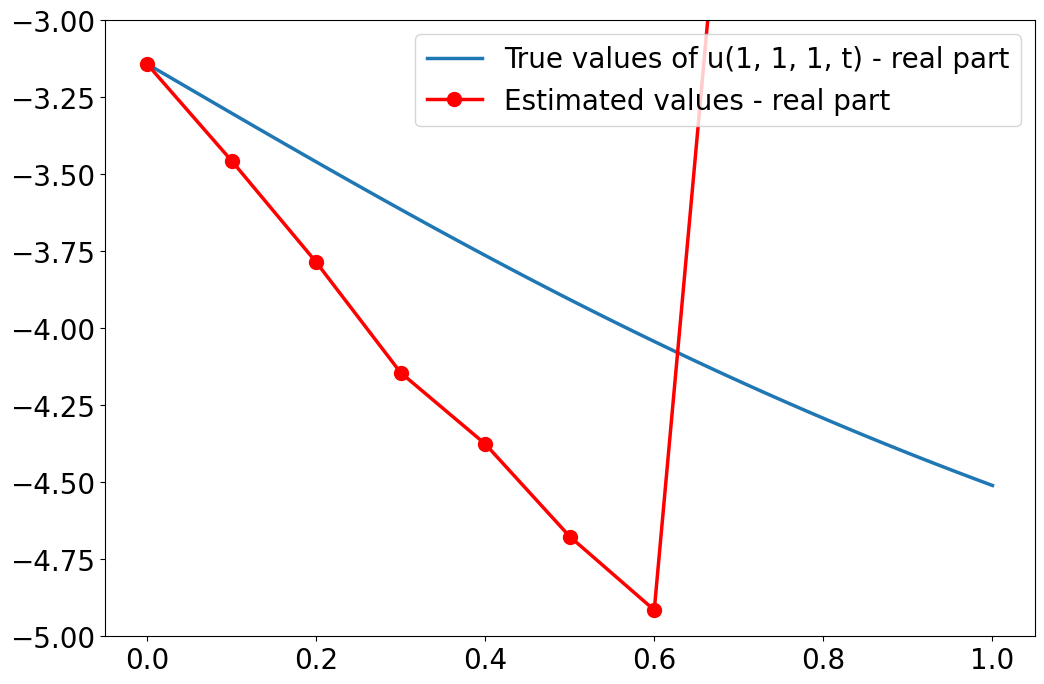

In [18]:
impose_ylim = True
y_lim = [-5,-3]

true_values_real = np.asarray(np_dictionary["analytic"])[0,:]
true_values_real = np.reshape(true_values_real, (101,))#[0:191]
t_values = np.arange(0, 1.01, 0.01)
estimated_values_real = np.asarray(np_dictionary["monte_carlo"])[0,0:8]
estimated_values_real = np.reshape(estimated_values_real, (8,))#[0:19]
t_estimated = np.arange(0, 0.8, 0.1)

plt.figure(figsize=(12, 8))
plt.plot(t_values, true_values_real, label='True values of u(1, 1, 1, t) - real part', lw=2.5)
plt.plot(t_estimated, estimated_values_real, 'ro-', label='Estimated values - real part', lw=2.5, ms=10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# plt.ylabel('true vs estimated values - real part')
if impose_ylim:
    plt.ylim(y_lim)
# plt.xlabel('t values')
# plt.axvline(x=0.32,color='red')

# plt.title('True vs estimated values of u(1, 1, 1, t) - real part')
plt.legend(loc='upper right',fontsize=20)
plt.show()

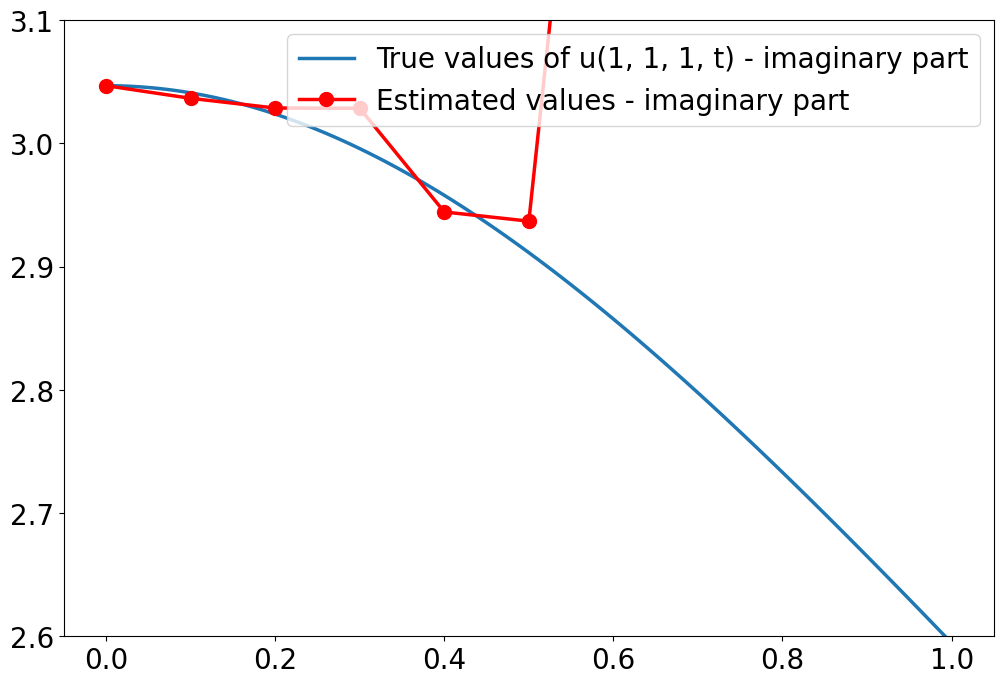

In [19]:
impose_ylim = True
y_lim = [2.6,3.1]

true_values_imaginary = np.asarray(np_dictionary["analytic"])[1,:]
true_values_imaginary = np.reshape(true_values_imaginary, (101,))#[0:191]
t_values = np.arange(0, 1.01, 0.01)
estimated_values_imaginary = np.asarray(np_dictionary["monte_carlo"])[1,0:8]
estimated_values_imaginary = np.reshape(estimated_values_imaginary, (8,))#[0:19]
t_estimated = np.arange(0, 0.8, 0.1)

plt.figure(figsize=(12, 8))
plt.plot(t_values, true_values_imaginary, label='True values of u(1, 1, 1, t) - imaginary part', lw=2.5)
plt.plot(t_estimated, estimated_values_imaginary, 'ro-', label='Estimated values - imaginary part', lw=2.5, ms=10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# plt.ylabel('true vs estimated values - imaginary part')
plt.ylabel('')
if impose_ylim:
    plt.ylim(y_lim)
# plt.xlabel('t values')
plt.xlabel('')
# plt.axvline(x=0.32,color='red')

# plt.title('True vs estimated values of u(1, 1, 1, t) - imaginary part')
plt.legend(loc='upper right',fontsize=20)
plt.show()